# Network Analysis
## Bluesky Twitter/X Discussion
In this notebook I will conduct the network analysis part for the report.
It will be performed on the reply thread dataset (`edges.csv`).
- part of EDA and data preparation
- reply network creation
- degree distribution analysis
- centrality analysis
- network visualization 
- analysis of connected components

Imported required libraries for data manipulation.

In [4]:
import csv
from collections import defaultdict
import pandas

Load the raw dataset and count posts/keyword to see if even collection was achieved across all keywords.

In [ ]:
with open ("data/posts.csv", "r", newline="", encoding="utf-8") as data:
    reader = csv.DictReader(data)
    kw_counts = defaultdict(int)
    for row in reader:
        kw_counts[row['keyword']] += 1
        
total = 0
for key in kw_counts:
    if kw_counts[key] != 0:
        total += kw_counts[key]


print (kw_counts)
print(total)

defaultdict(<class 'int'>, {'twitter': 2057, 'elon': 2009, 'twitter refugee': 2007, 'bluesky vs twitter': 2009, 'twitter is dead': 2016, 'quit twitter': 2008, 'miss twitter': 2059})
14165


Use a pandas dataframe and see basic statistics of the dataset.

In [ ]:
df = pandas.read_csv("data/posts.csv")
print(f"Total posts: {len(df)}")
print(f"Duplicates: {df['uri'].duplicated().sum()}")
print(f"Is reply True: {df['is_reply'].sum()}")
print(f"Is reply False: {(df['is_reply'] == False).sum()}")
print(f"\nReply count stats:")
print(df['reply_count'].describe())

Total posts: 14165
Duplicates: 120
Is reply True: 6623
Is reply False: 7542

Reply count stats:
count    14165.000000
mean         1.115708
std         17.730914
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       1996.000000
Name: reply_count, dtype: float64


Get rid of dupes (based on the uri of the post) - better than checking for dupes on text, since multiple users can post the same text.

In [7]:
print(f"Prior to removing dupes: {len(df)}")
df = df.drop_duplicates(subset="uri")
print(f"After removing dupes: {len(df)}")
df.to_csv("data/posts_no_dupes.csv", index = False)

Prior to removing dupes: 14165
After removing dupes: 14045


See the top-10 posts with most replies. They will be used as seed posts for reply thread collection.

In [8]:
sorted_df = df.sort_values(by="reply_count", ascending=False)

top_replied_posts_df = sorted_df[["uri","text","reply_count", "keyword"]].head(10)
top_replied_posts_df.to_csv("data/top_replied_posts.csv", index = False)
uris_all = [uri for uri in top_replied_posts_df["uri"]]
print(uris_all)


['at://did:plc:xyddpg6usmgh2t2jgf4e37yk/app.bsky.feed.post/3mhvfinvcgc2q', 'at://did:plc:ul5n745uxwymqppvpiwtpoa5/app.bsky.feed.post/3mkej7zyfnk2h', 'at://did:plc:5mqpgxjffcckasqv7h6g7itu/app.bsky.feed.post/3m3crrs6ark2y', 'at://did:plc:tsf3qulwq25yo27j6eznkfix/app.bsky.feed.post/3mc2crp2ahc27', 'at://did:plc:4q4ziw4qk2hxxaxfu7jweuey/app.bsky.feed.post/3mmak4a4rns2k', 'at://did:plc:ji7lroxun3yvv2pxhcf7jqsn/app.bsky.feed.post/3mmagsxpukq22', 'at://did:plc:37ukqjgnt2puqbdvxo6jw4le/app.bsky.feed.post/3mmafhs4fws2z', 'at://did:plc:t4i3a4fawuzge3dsw2i2h2fw/app.bsky.feed.post/3mbhvqutprk2a', 'at://did:plc:t46sqvutibvsmjgwn6r6izve/app.bsky.feed.post/3ltfs7bk3js2i', 'at://did:plc:dy4mk6ej5d7hlqgfeqjft3hd/app.bsky.feed.post/3mcnhpj3qj22j']


Identify the top 10 most-replied posts specifically from the "bluesky vs twitter" keyword, as this is the most directly relevant keyword to our research question.

In [9]:
top_replied_posts_twtvsbsky = sorted_df[sorted_df['keyword'] == 'bluesky vs twitter'][["uri",'text', 'reply_count', 'keyword']].head(10)
print(top_replied_posts_twtvsbsky)
uris_twtvsbsky = [uri for uri in top_replied_posts_twtvsbsky["uri"]]

                                                    uri  \
6935  at://did:plc:t46sqvutibvsmjgwn6r6izve/app.bsky...   
6322  at://did:plc:3iwge6tzr76tkt6xdwyfs6mr/app.bsky...   
7333  at://did:plc:jimtocu7irkkkupvh7g34rhs/app.bsky...   
6394  at://did:plc:rkfwqt5jedajtdnkx5kvedfo/app.bsky...   
6459  at://did:plc:4vrssqepg6uj4tj5us7tnfgt/app.bsky...   
6999  at://did:plc:psxf6wrijwkudvi2etmxsess/app.bsky...   
7989  at://did:plc:sgti3jsgu3luif24tokvth3a/app.bsky...   
6708  at://did:plc:kyphkmluigfakab42kfn5ri2/app.bsky...   
6916  at://did:plc:cak4klqoj3bqgk5rj6b4f5do/app.bsky...   
7051  at://did:plc:slwpvr5uwq7dqv4nur35dlji/app.bsky...   

                                                   text  reply_count  \
6935  Twitter vs Threads vs BlueSky \r\n\r\nHave def...           83   
6322  i was wondering if we could maybe argue about ...           56   
7333  I've been keeping a closer eye on traffic from...           41   
6394  The playoffs are alive on BlueSky, the officia...       

Combine the 20 post URIs into one list for thread fetching based on URI.

In [10]:
uris = uris_all + uris_twtvsbsky
print(uris)
print(len(uris))

['at://did:plc:xyddpg6usmgh2t2jgf4e37yk/app.bsky.feed.post/3mhvfinvcgc2q', 'at://did:plc:ul5n745uxwymqppvpiwtpoa5/app.bsky.feed.post/3mkej7zyfnk2h', 'at://did:plc:5mqpgxjffcckasqv7h6g7itu/app.bsky.feed.post/3m3crrs6ark2y', 'at://did:plc:tsf3qulwq25yo27j6eznkfix/app.bsky.feed.post/3mc2crp2ahc27', 'at://did:plc:4q4ziw4qk2hxxaxfu7jweuey/app.bsky.feed.post/3mmak4a4rns2k', 'at://did:plc:ji7lroxun3yvv2pxhcf7jqsn/app.bsky.feed.post/3mmagsxpukq22', 'at://did:plc:37ukqjgnt2puqbdvxo6jw4le/app.bsky.feed.post/3mmafhs4fws2z', 'at://did:plc:t4i3a4fawuzge3dsw2i2h2fw/app.bsky.feed.post/3mbhvqutprk2a', 'at://did:plc:t46sqvutibvsmjgwn6r6izve/app.bsky.feed.post/3ltfs7bk3js2i', 'at://did:plc:dy4mk6ej5d7hlqgfeqjft3hd/app.bsky.feed.post/3mcnhpj3qj22j', 'at://did:plc:t46sqvutibvsmjgwn6r6izve/app.bsky.feed.post/3ltfs7bk3js2i', 'at://did:plc:3iwge6tzr76tkt6xdwyfs6mr/app.bsky.feed.post/3mf5ta52w7c2p', 'at://did:plc:jimtocu7irkkkupvh7g34rhs/app.bsky.feed.post/3lkvp53pxvk27', 'at://did:plc:rkfwqt5jedajtdnkx5kvedf

`fetch_thread.py` script is then run using the list of URIs above. The thread edges are saved into `data/edges.csv`.

Load `edges.csv` dataset. Each row is a directed reply relationship between two different users.

In [11]:
edges_df = pandas.read_csv('data/edges.csv')
print(f"Total edges: {len(edges_df)}")
print(f"Unique from_did: {edges_df['from_did'].nunique()}")
print(f"Unique to_did: {edges_df['to_did'].nunique()}")

Total edges: 2825
Unique from_did: 2062
Unique to_did: 503


## **Network Analysis**

#### Reply network

Construct a weighted digraph from the edge dataset using NetworkX library.
- **Nodes**: unique bluesky users (identified by their DID)
- **Edges**: pointing FROM replier TO recipient
- **Weight**: num of times one user has replied to another across several different posts

In [12]:
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print(edges_df.head())

                           from_did                    from_handle  \
0  did:plc:zzxf5s4ino5zlgbvxunv63qg       jamesdean930.bsky.social   
1  did:plc:zz6l5qihitnfnjiwntm63f53  azraelthunderbolt.bsky.social   
2  did:plc:kytjaohsllajeyzsbfkwsdhl         aialbumart.bsky.social   
3  did:plc:zvyrl5sfoesli57zmhkbegdf       ripthisjoint.bsky.social   
4  did:plc:zualyjrxryslowdgvxwwqzyd    rathernotreveal.bsky.social   

                                           from_text  \
0                                           No Shit!   
1                                                NaN   
2  HAHA! \nAlso..\nP.P Barnum and His little frie...   
3  It’s like we are living in the tiki lounge in ...   
4  Should have received wide play from the "Mains...   

            from_created_at                            to_did  \
0  2026-03-26T15:42:58.936Z  did:plc:xyddpg6usmgh2t2jgf4e37yk   
1  2026-03-25T16:47:08.182Z  did:plc:xyddpg6usmgh2t2jgf4e37yk   
2  2026-03-25T16:50:21.485Z  did:plc:zz6l5qihit

In [13]:
G = nx.DiGraph()

for _, row in edges_df.iterrows():
    from_did = row['from_did']
    to_did = row['to_did']
    from_handle = row['from_handle']
    to_handle = row['to_handle']

    if not G.has_node(from_did):
        G.add_node(from_did, handle=from_handle)
    if not G.has_node(to_did):
        G.add_node(to_did, handle=to_handle)

    if G.has_edge(from_did, to_did):
        G[from_did][to_did]['weight'] += 1
    else:
        G.add_edge(from_did, to_did, weight=1)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.6f}")

Nodes: 2072
Edges: 2486
Density: 0.000579


Compute **in-degree** (replies received), as well as **out-degree** (users replied to) for all nodes (users).

In [14]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"Average in-degree: {sum(in_degrees.values()) / len(in_degrees):.2f}")
print(f"Average out-degree: {sum(out_degrees.values()) / len(out_degrees):.2f}")
print(f"Max in-degree: {max(in_degrees.values())}")
print(f"Max out-degree: {max(out_degrees.values())}")

Average in-degree: 1.20
Average out-degree: 1.20
Max in-degree: 196
Max out-degree: 65


Plot the in- and out-degree distributions.

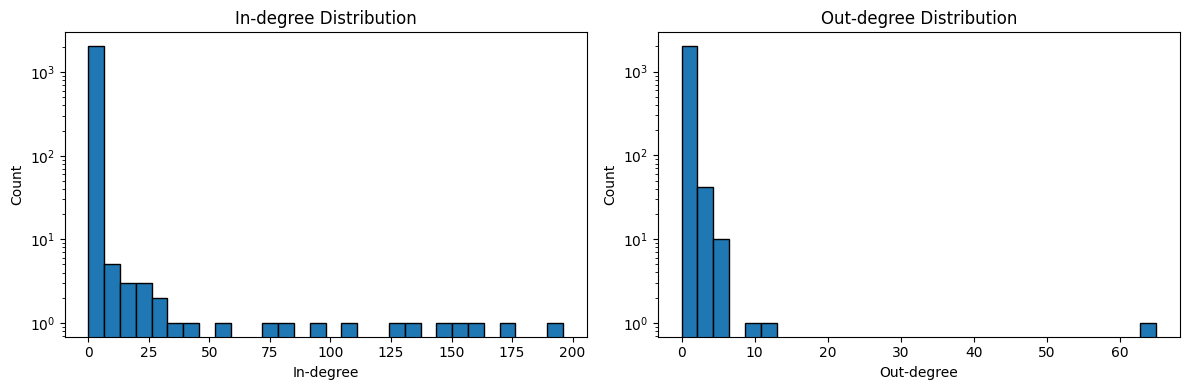

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

in_deg_values = list(in_degrees.values())
out_deg_values = list(out_degrees.values())

ax1.hist(in_deg_values, bins=30, edgecolor='black')
ax1.set_title('In-degree Distribution')
ax1.set_xlabel('In-degree')
ax1.set_ylabel('Count')
ax1.set_yscale('log')

ax2.hist(out_deg_values, bins=30, edgecolor='black')
ax2.set_title('Out-degree Distribution')
ax2.set_xlabel('Out-degree')
ax2.set_ylabel('Count')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('figures/degree_distribution.png', dpi=150)
plt.show()

As expected, they show long-tail distributions (normal for social networks).

**Centrality** analysis.
- **Degree centrality**: connectivity of nodes overall
- **Betweenness centrality**: nodes that act as bridges between distinct clusters
- **Eigenvector centrality**: nodes connected to other influential nodes
- **In-degree centrality**: who receives the most replies total

In [16]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality failed to converge, using degree centrality as fallback")
    eigenvector_centrality = degree_centrality

in_degree_centrality = nx.in_degree_centrality(G)

Getting distribution statistics for every single centrality measure.

In [17]:
def centrality_stats(centrality_dict, name):
    values = list(centrality_dict.values())
    print(f"\n{name}:")
    print(f"  Mean:    {np.mean(values):.6f}")
    print(f"  Std Dev: {np.std(values):.6f}")
    print(f"  Min:     {np.min(values):.6f}")
    print(f"  25th:    {np.percentile(values, 25):.6f}")
    print(f"  50th:    {np.percentile(values, 50):.6f}")
    print(f"  75th:    {np.percentile(values, 75):.6f}")
    print(f"  Max:     {np.max(values):.6f}")

centrality_stats(degree_centrality, "Degree Centrality")
centrality_stats(betweenness_centrality, "Betweenness Centrality")
centrality_stats(eigenvector_centrality, "Eigenvector Centrality")
centrality_stats(in_degree_centrality, "In-degree Centrality")


Degree Centrality:
  Mean:    0.001159
  Std Dev: 0.005124
  Min:     0.000483
  25th:    0.000483
  50th:    0.000483
  75th:    0.000966
  Max:     0.094640

Betweenness Centrality:
  Mean:    0.000002
  Std Dev: 0.000030
  Min:     0.000000
  25th:    0.000000
  50th:    0.000000
  75th:    0.000000
  Max:     0.001278

Eigenvector Centrality:
  Mean:    0.003097
  Std Dev: 0.021749
  Min:     0.000000
  25th:    0.000000
  50th:    0.000000
  75th:    0.000000
  Max:     0.707159

In-degree Centrality:
  Mean:    0.000579
  Std Dev: 0.004943
  Min:     0.000000
  25th:    0.000000
  50th:    0.000000
  75th:    0.000000
  Max:     0.094640


Getting the top-10 most influential nodes for each of the 4 centrality measures.

In [18]:
def top_nodes(centrality_dict, G, n=10, label=""):
    print(f"\nTop {n} nodes by {label}:")
    sorted_nodes = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:n]
    for did, score in sorted_nodes:
        handle = G.nodes[did].get('handle', did)
        print(f"  {handle}: {score:.6f}")

top_nodes(in_degree_centrality, G, label="In-degree Centrality")
top_nodes(betweenness_centrality, G, label="Betweenness Centrality")
top_nodes(eigenvector_centrality, G, label="Eigenvector Centrality")


Top 10 nodes by In-degree Centrality:
  mikedrucker.bsky.social: 0.094640
  mollyploofkins.bsky.social: 0.084017
  markhamillofficial.bsky.social: 0.076775
  ottoenglish.bsky.social: 0.074843
  urocklive1.bsky.social: 0.070497
  contrapoints.bsky.social: 0.066152
  clarajeffery.bsky.social: 0.061323
  joycecaroloates.bsky.social: 0.053597
  markjacob.bsky.social: 0.044423
  anno1540.bsky.social: 0.040077

Top 10 nodes by Betweenness Centrality:
  anno1540.bsky.social: 0.001278
  markhamillofficial.bsky.social: 0.000254
  r5-to-philly.bsky.social: 0.000130
  missjanequeen.bsky.social: 0.000127
  tryn2bkind.bsky.social: 0.000126
  ottoenglish.bsky.social: 0.000126
  contrapoints.bsky.social: 0.000106
  bluebirdone.bsky.social: 0.000101
  aremoreequal.bsky.social: 0.000085
  andrewdaw.bsky.social: 0.000077

Top 10 nodes by Eigenvector Centrality:
  anno1540.bsky.social: 0.707159
  mtfromcc.bsky.social: 0.087689
  latina4jesusdshw.bsky.social: 0.087689
  politicalodor.substack.com: 0.0876

Run the **Louvain algorithm** on the undirected version of the digraph to find distinct clusters of users that interact more with other users within the clusters than others.
We also use a **modularity** score to gauge how distinct the found communities are to each other (>= 0.7 is strong).

In [19]:
G_undirected = nx.to_undirected(G)

dLouvainComms = community_louvain.best_partition(G_undirected)

louvanCommNum = max([y for (x, y) in dLouvainComms.items()]) + 1
lLouvainComms = [set() for _ in range(louvanCommNum)]
for (node, clusId) in dLouvainComms.items():
    lLouvainComms[clusId].add(node)

print(f"Number of communities: {louvanCommNum}")
print(f"Modularity: {community_louvain.modularity(dLouvainComms, G_undirected):.4f}")

comm_sizes = [len(c) for c in lLouvainComms]
print(f"Community sizes: min={min(comm_sizes)}, max={max(comm_sizes)}, mean={np.mean(comm_sizes):.1f}")

for node, comm_id in dLouvainComms.items():
    G.nodes[node]['louvain'] = comm_id

Number of communities: 25
Modularity: 0.9085
Community sizes: min=2, max=204, mean=82.9


Plot the community sizes (largest -> smallest)

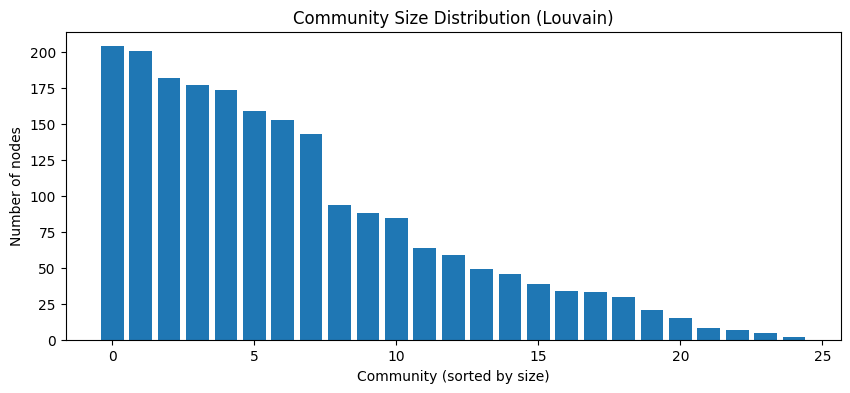

In [20]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(comm_sizes)), sorted(comm_sizes, reverse=True))
plt.title('Community Size Distribution (Louvain)')
plt.xlabel('Community (sorted by size)')
plt.ylabel('Number of nodes')
plt.savefig('figures/community_sizes.png', dpi=150)
plt.show()

Visualize the largest weakly connected component (Kamada-Kawai layout).
- **Node size** - in-degree centrality
- **Node_colour** - Louvain community it belongs to
- Only the top 10 nodes by in-degree are labelled or else the graph is an unreadable mess

Largest component: 1704 nodes, 2066 edges


C:\Users\danie\AppData\Local\Temp\ipykernel_37016\483184124.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20', len(unique_comms))


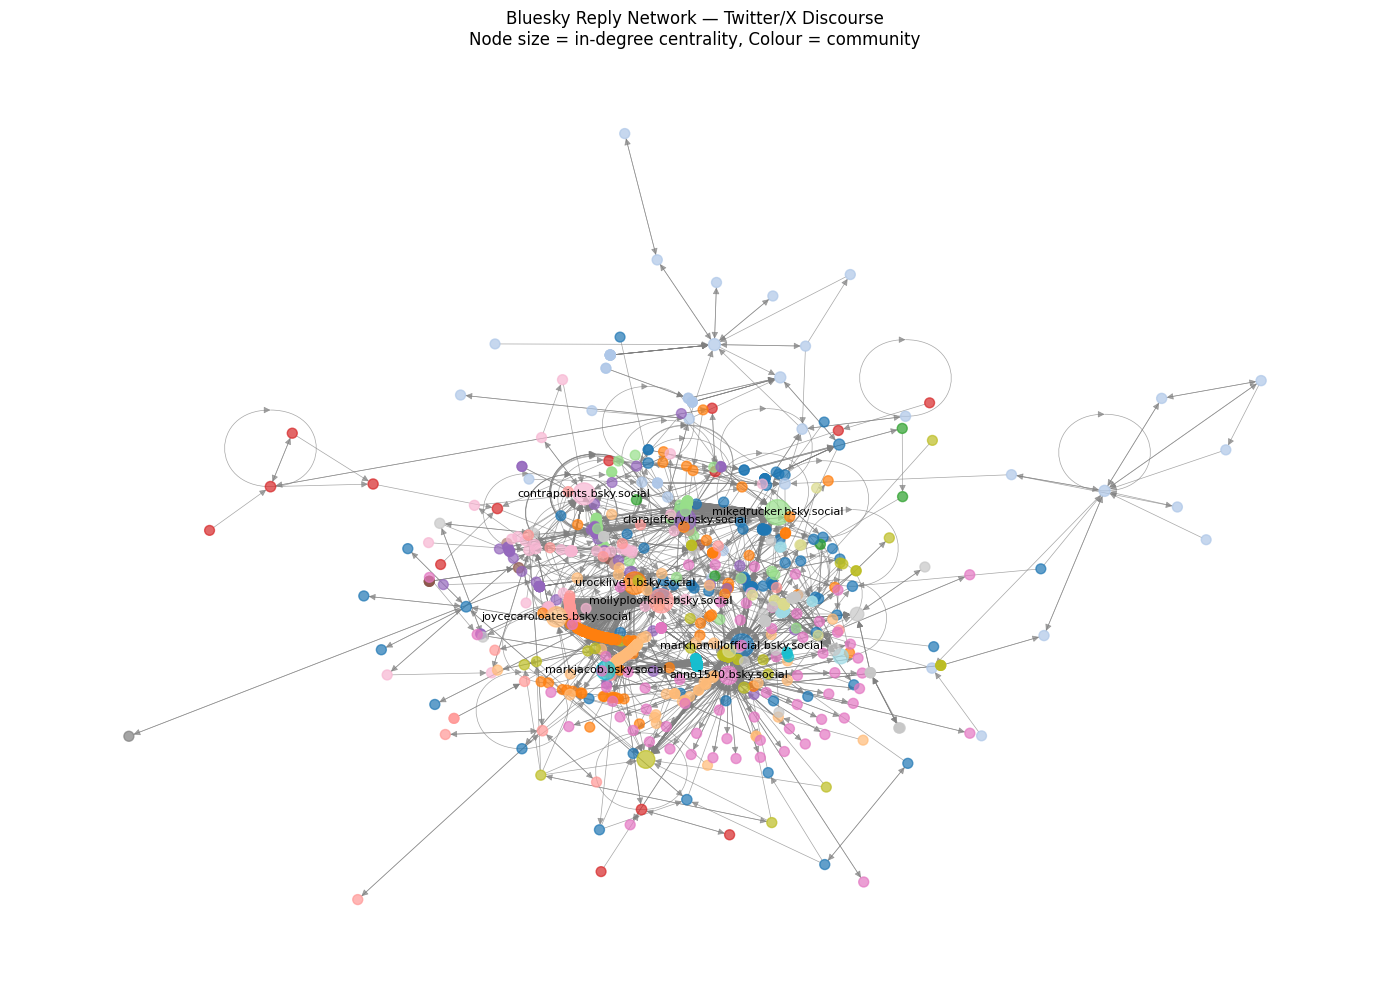

In [21]:
largest_cc = max(nx.weakly_connected_components(G), key=len)
G_sub = G.subgraph(largest_cc).copy()

print(f"Largest component: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")

comm_ids = [dLouvainComms.get(n, 0) for n in G_sub.nodes()]
unique_comms = list(set(comm_ids))
color_map = cm.get_cmap('tab20', len(unique_comms))
node_colors = [color_map(unique_comms.index(c)) for c in comm_ids]

node_sizes = [in_degree_centrality.get(n, 0) * 3000 + 50 for n in G_sub.nodes()]

pos = nx.kamada_kawai_layout(G_sub)

plt.figure(figsize=(14, 10))
nx.draw_networkx(
    G_sub,
    pos=pos,
    node_color=node_colors,
    node_size=node_sizes,
    arrows=True,
    with_labels=False,
    alpha=0.7,
    edge_color='grey',
    width=0.5
)

top_did = sorted(in_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_labels = {did: G.nodes[did].get('handle', did) for did, _ in top_did if did in G_sub.nodes()}
nx.draw_networkx_labels(G_sub, pos, labels=top_labels, font_size=8)

plt.title('Bluesky Reply Network — Twitter/X Discourse\nNode size = in-degree centrality, Colour = community')
plt.axis('off')
plt.tight_layout()
plt.savefig('figures/network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
nx.readwrite.write_graphml(G, 'data/reply_network.graphml', infer_numeric_types=True)
print("Saved to reply_network.graphml")

Saved to reply_network.graphml


Now, look at connectivity of produced network.
- **Weakly connected**: edge direction is ignored. Is point A reachable from B using any path?
- **Strongly connected**: can you reach B from A and return back using directed edges?

In [23]:
weak_components = list(nx.weakly_connected_components(G))
weak_components_sorted = sorted(weak_components, key=len, reverse=True)

print(f"Number of weakly connected components: {len(weak_components)}")
print(f"Largest component: {len(weak_components_sorted[0])} nodes ({len(weak_components_sorted[0])/G.number_of_nodes()*100:.1f}% of network)")
print(f"Isolated nodes (size 1): {sum(1 for c in weak_components if len(c) == 1)}")
print(f"Small components (size 2-5): {sum(1 for c in weak_components if 2 <= len(c) <= 5)}")

strong_components = list(nx.strongly_connected_components(G))
print(f"\nNumber of strongly connected components: {len(strong_components)}")
print(f"Largest strongly connected component: {max(len(c) for c in strong_components)} nodes")

Number of weakly connected components: 7
Largest component: 1704 nodes (82.2% of network)
Isolated nodes (size 1): 0
Small components (size 2-5): 0

Number of strongly connected components: 1865
Largest strongly connected component: 66 nodes


Let's look at the most replied-to user handles from the top 5 communities in order to identify who is the most influential figure within each community.

In [24]:
did_to_handle = {did: G.nodes[did].get('handle', did) for did in G.nodes()}

comm_members = {}
for node, comm_id in dLouvainComms.items():
    if comm_id not in comm_members:
        comm_members[comm_id] = []
    comm_members[comm_id].append(did_to_handle[node])

comm_sorted = sorted(comm_members.items(), key=lambda x: len(x[1]), reverse=True)

print("Top 5 communities by size:\n")
for comm_id, members in comm_sorted[:5]:
    print(f"Community {comm_id} ({len(members)} members):")
    member_dids = [did for did, cid in dLouvainComms.items() if cid == comm_id]
    top_members = sorted(
        [(did_to_handle[did], in_degree_centrality.get(did, 0)) for did in member_dids],
        key=lambda x: x[1], reverse=True
    )[:10]
    for handle, score in top_members:
        print(f"  {handle}: in-degree {score:.6f}")
    print()

Top 5 communities by size:

Community 0 (204 members):
  markhamillofficial.bsky.social: in-degree 0.076775
  stef47.bsky.social: in-degree 0.004346
  missjanequeen.bsky.social: in-degree 0.002414
  cluestore.bsky.social: in-degree 0.002414
  r5-to-philly.bsky.social: in-degree 0.001931
  pachyaena.bsky.social: in-degree 0.001931
  nettem.bsky.social: in-degree 0.001449
  jhchrist.bsky.social: in-degree 0.001449
  onedandelion.bsky.social: in-degree 0.001449
  justsayin-fromx.bsky.social: in-degree 0.001449

Community 6 (201 members):
  mikedrucker.bsky.social: in-degree 0.094640
  norapaterson.bsky.social: in-degree 0.001449
  metaltxt.bsky.social: in-degree 0.000966
  pornofoleyartist.bsky.social: in-degree 0.000966
  bimblinghill.bsky.social: in-degree 0.000966
  zenzinnia.bsky.social: in-degree 0.000483
  pattifink.bsky.social: in-degree 0.000483
  caodragao.bsky.social: in-degree 0.000483
  willrob3737.bsky.social: in-degree 0.000483
  excludedmugwump.bsky.social: in-degree 0.0004

#### Network 2

Evaluate if a second mention network's a good idea.

In [25]:
import re
import pandas as pd

posts_df = pd.read_csv('data/posts_no_dupes.csv')
def extract_mentions(text):
    if pd.isna(text):
        return []
    return re.findall(r'@[\w.]+', text)

posts_df['mentions'] = posts_df['text'].apply(extract_mentions)

# how many posts have mentions
has_mentions = posts_df[posts_df['mentions'].apply(len) > 0]
print(f"Posts with at least one mention: {len(has_mentions)} out of {len(posts_df)}")

from collections import Counter
all_mentions = [m for mentions in posts_df['mentions'] for m in mentions]
mention_counts = Counter(all_mentions)
print(f"\nTotal mentions: {len(all_mentions)}")
print(f"Unique mentions: {len(mention_counts)}")
print(f"\nTop 20 most mentioned:")
for mention, count in mention_counts.most_common(20):
    print(f"  {mention}: {count}")

Posts with at least one mention: 647 out of 14045

Total mentions: 942
Unique mentions: 761

Top 20 most mentioned:
  @bsky.app: 21
  @democrats.senate.gov: 9
  @thiswillhol...: 8
  @democrats.org: 7
  @altmetric.com: 6
  @aoc.bsky.social: 5
  @jay.bsky.team: 5
  @hankgreen.bsky.social: 5
  @legacyggbr: 4
  @B8esportsGG: 4
  @glennkirschner.bsky.social: 4
  @marcelias.bsky.social: 4
  @stevevladeck.bsky.social: 4
  @x3em: 4
  @mcuban.bsky.social: 4
  @AlexC_NJD: 4
  @NJD_OnTheRush: 4
  @moulton.house.gov: 4
  @FalconsEsport: 3
  @1mongolz: 3


No - not enough posts contain mentions.

Back to network 1. Let's have a look at edge weight distribution to make sure there are edges with weight > 1. That indicates that the same user replied to the same person multiple times in different posts (showcasing a conversation between them)

In [26]:
weights = [d['weight'] for u, v, d in G.edges(data=True)]
print(f"Max weight: {max(weights)}")
print(f"Edges with weight > 1: {sum(1 for w in weights if w > 1)}")
print(f"Total edges: {len(weights)}")

Max weight: 27
Edges with weight > 1: 234
Total edges: 2486


Closer look at the size of each weakly connected component.

In [27]:
weak_components_sorted = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
for i, comp in enumerate(weak_components_sorted):
    print(f"Component {i+1}: {len(comp)} nodes")


Component 1: 1704 nodes
Component 2: 182 nodes
Component 3: 59 nodes
Component 4: 39 nodes
Component 5: 34 nodes
Component 6: 33 nodes
Component 7: 21 nodes
